# Telemetry Sanity Checks (Synthetic Duolingo-style Data)

Goal: lock in correctness so the telemetry behaves like the product story.

Checklist
- DAU / WAU / MAU trends look smooth and reasonable
- No impossible timestamps (sessions before signup, negative durations, etc.)
- Funnels make sense (lesson_started ≥ lesson_completed, etc.)
- Control vs treatment is identical before experiment rollout

Plots first
- DAU over time
- DAU split by variant
- Avg sessions per active user over time
- Avg streak length over time


In [98]:
# Imports + Settings
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = Path("../data")  # <-- adjust if needed
OUT_FIG = Path("../outputs/figures")
OUT_TAB = Path("../outputs/tables")
OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB.mkdir(parents=True, exist_ok=True)

def assert_true(cond: bool, msg: str):
    if not bool(cond):
        raise AssertionError(msg)

def pct(x: float) -> str:
    return f"{100*x:.2f}%"

In [99]:
# Load CSVs
users = pd.read_csv(DATA_DIR / "users.csv")
sessions = pd.read_csv(DATA_DIR / "sessions.csv")
events = pd.read_csv(DATA_DIR / "events.csv")
lessons = pd.read_csv(DATA_DIR / "lessons.csv")

print("Shapes")
print(" users   :", users.shape)
print(" sessions:", sessions.shape)
print(" events  :", events.shape)
print(" lessons :", lessons.shape)

display(users.head(2))
display(sessions.head(2))
display(events.head(2))
display(lessons.head(2))


Shapes
 users   : (10000, 13)
 sessions: (1085100, 7)
 events  : (13383479, 15)
 lessons : (256, 7)


,user_id,signup_date,signup_time,signup_channel,campaign_id,country,language_target,device_os,app_version,timezone,signup_platform,is_premium_at_signup,variant
0,100001,2025-01-01,2025-01-01 07:07:38,paid,tiktok_2025w10,US,EN,iOS,1.12.3,Australia/Perth,mobile,False,control
1,100002,2025-01-01,2025-01-01 06:19:54,paid,meta_2025w06,CN,ES,iOS,1.12.4,Australia/Perth,mobile,False,treatment


,session_id,user_id,session_start,session_end,session_duration_sec,device_os,app_version
0,sess_00000001,100001,2025-01-21 17:54:56,2025-01-21 18:05:28,632,iOS,1.12.3
1,sess_00000002,100001,2025-01-21 18:25:28,2025-01-21 18:29:46,258,iOS,1.12.3


,event_id,user_id,session_id,event_time,event_date,event_name,screen,language_target,lesson_id,xp_delta,hearts_delta,streak_length,is_premium,experiment_id,variant
0,evt_000000001,100001,NaN,2025-01-01 07:07:38,2025-01-01,signup,onboarding,EN,NaN,0,0,0,False,exp_streak_nudge,control
1,evt_000000002,100001,NaN,2025-01-01 07:24:38,2025-01-01,onboarding_completed,onboarding,EN,NaN,0,0,0,False,exp_streak_nudge,control


,lesson_id,unit_id,skill,difficulty,topic,expected_duration_sec,expected_xp
0,L_U01_S01_01,U01,Past Tense,1,Work,230,13
1,L_U01_S01_02,U01,Past Tense,1,Daily Life,215,14


In [100]:
# Parse Types + Canonicalize + Sort
# ---- Parse datetimes ----
users["signup_time"] = pd.to_datetime(users["signup_time"], errors="coerce")
users["signup_date"] = pd.to_datetime(users["signup_date"], errors="coerce").dt.date

sessions["session_start"] = pd.to_datetime(sessions["session_start"], errors="coerce")
sessions["session_end"] = pd.to_datetime(sessions["session_end"], errors="coerce")

events["event_time"] = pd.to_datetime(events["event_time"], errors="coerce")
# events.event_date stored as date string in generator; keep date for grouping
events["event_date"] = pd.to_datetime(events["event_date"], errors="coerce").dt.date

# ---- Normalize empty strings vs NaN (important for joins) ----
for col in ["campaign_id"]:
    if col in users.columns:
        users[col] = users[col].fillna("").astype(str)

for col in ["session_id", "lesson_id"]:
    if col in events.columns:
        events[col] = events[col].fillna("").astype(str)

# ---- Sort (deterministic) ----
sessions = sessions.sort_values(["user_id", "session_start"]).reset_index(drop=True)
events = events.sort_values(["user_id", "event_time"]).reset_index(drop=True)

# quick null checks on parsed timestamps
assert_true(users["signup_time"].notna().all(), "Some users.signup_time failed to parse")
assert_true(sessions["session_start"].notna().all(), "Some sessions.session_start failed to parse")
assert_true(sessions["session_end"].notna().all(), "Some sessions.session_end failed to parse")
assert_true(events["event_time"].notna().all(), "Some events.event_time failed to parse")
assert_true(events["event_date"].notna().all(), "Some events.event_date failed to parse")

print("Parsed + sorted OK")


Parsed + sorted OK


In [101]:
# Column Presence + Basic Domains
REQ_USERS = {
    "user_id","signup_date","signup_time","signup_channel","campaign_id","country","language_target",
    "device_os","app_version","timezone","signup_platform","is_premium_at_signup","variant"
}
REQ_SESS = {"session_id","user_id","session_start","session_end","session_duration_sec","device_os","app_version"}
REQ_EVT  = {"event_id","user_id","session_id","event_time","event_date","event_name","screen","language_target",
            "lesson_id","xp_delta","hearts_delta","streak_length","is_premium","experiment_id","variant"}
REQ_LESS = {"lesson_id","unit_id","skill","difficulty","topic","expected_duration_sec","expected_xp"}

assert_true(REQ_USERS.issubset(users.columns), f"users missing: {sorted(REQ_USERS - set(users.columns))}")
assert_true(REQ_SESS.issubset(sessions.columns), f"sessions missing: {sorted(REQ_SESS - set(sessions.columns))}")
assert_true(REQ_EVT.issubset(events.columns), f"events missing: {sorted(REQ_EVT - set(events.columns))}")
assert_true(REQ_LESS.issubset(lessons.columns), f"lessons missing: {sorted(REQ_LESS - set(lessons.columns))}")

print("Variants:", users["variant"].value_counts(dropna=False).to_dict())
print("Event names (sample):", sorted(events["event_name"].unique())[:15], "...")
print("Screens (sample):", sorted(events["screen"].unique())[:15], "...")


Variants: {'treatment': 5041, 'control': 4959}
Event names (sample): ['app_background', 'app_open', 'lesson_completed', 'lesson_started', 'onboarding_completed', 'paywall_shown', 'purchase', 'push_opened', 'push_received', 'question_answered', 'signup', 'streak_broken', 'streak_incremented'] ...
Screens (sample): ['home', 'lesson', 'lesson_result', 'onboarding', 'shop'] ...


In [102]:
# PK / FK Integrity
# ---- PK uniqueness ----
assert_true(users["user_id"].is_unique, "users.user_id not unique")
assert_true(sessions["session_id"].is_unique, "sessions.session_id not unique")
assert_true(events["event_id"].is_unique, "events.event_id not unique")
assert_true(lessons["lesson_id"].is_unique, "lessons.lesson_id not unique")

# ---- FK integrity ----
uids = set(users["user_id"].astype(int))
assert_true(sessions["user_id"].isin(uids).all(), "sessions.user_id contains unknown users")
assert_true(events["user_id"].isin(uids).all(), "events.user_id contains unknown users")

sess_ids = set(sessions["session_id"].astype(str))
evt_sess = events["session_id"].astype(str)
bad_sess_ref = evt_sess[(evt_sess != "") & (~evt_sess.isin(sess_ids))]
assert_true(len(bad_sess_ref) == 0, f"events.session_id references missing sessions (n={len(bad_sess_ref)})")

# lesson_id rules for lesson-flow events
lesson_flow = events["event_name"].isin(["lesson_started","question_answered","lesson_completed"])
assert_true((events.loc[lesson_flow, "lesson_id"] != "").all(), "lesson flow events with empty lesson_id")
assert_true(events.loc[lesson_flow, "lesson_id"].isin(set(lessons["lesson_id"])).all(),
            "lesson flow events referencing unknown lesson_id")

print("PK/FK checks passed.")

PK/FK checks passed.


In [103]:
# Session Duration + Timestamp Invariants
# session ordering + duration
assert_true((sessions["session_end"] >= sessions["session_start"]).all(), "Some sessions have end < start")
assert_true((sessions["session_duration_sec"] >= 0).all(), "Some sessions have negative duration")

# recompute duration and compare
dur_recalc = (sessions["session_end"] - sessions["session_start"]).dt.total_seconds().round().astype(int)
dur_stored = sessions["session_duration_sec"].astype(int)
diff = (dur_recalc - dur_stored).abs()
print("Duration diff summary (seconds):")
print(diff.describe())

assert_true((diff <= 2).all(), "Session duration mismatch > 2 seconds found")

# sessions not before signup
sessions_u = sessions.merge(users[["user_id","signup_time"]], on="user_id", how="left")
bad = sessions_u[sessions_u["session_start"] < sessions_u["signup_time"]]
assert_true(len(bad) == 0, f"Found sessions before signup_time (n={len(bad)})")

# events not before signup
events_u = events.merge(users[["user_id","signup_time"]], on="user_id", how="left")
bad_evt = events_u[events_u["event_time"] < events_u["signup_time"]]
assert_true(len(bad_evt) == 0, f"Found events before signup_time (n={len(bad_evt)})")

print("Session/event timestamp invariants passed.")

Duration diff summary (seconds):
count    1085100.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
dtype: float64
Session/event timestamp invariants passed.


In [104]:
# Event Time Within Session Window
# only for events that have a session_id
evt_in_sess = events[events["session_id"] != ""].merge(
    sessions[["session_id","session_start","session_end"]],
    on="session_id",
    how="left"
)

assert_true(evt_in_sess["session_start"].notna().all(), "Some events have session_id but session missing after join")

too_early = evt_in_sess[evt_in_sess["event_time"] < evt_in_sess["session_start"]]
too_late  = evt_in_sess[evt_in_sess["event_time"] > evt_in_sess["session_end"]]

assert_true(len(too_early) == 0, f"Events before session_start found (n={len(too_early)})")
assert_true(len(too_late) == 0, f"Events after session_end found (n={len(too_late)})")

print("Event-in-session window checks passed.")

Event-in-session window checks passed.


In [105]:
evt_in_sess = events[events["session_id"] != ""].merge(
    sessions[["session_id","session_start","session_end"]],
    on="session_id",
    how="left"
)

too_early = evt_in_sess[evt_in_sess["event_time"] < evt_in_sess["session_start"]].copy()
too_early["gap_sec"] = (too_early["event_time"] - too_early["session_start"]).dt.total_seconds()

print("n too_early:", len(too_early))
print(too_early["event_name"].value_counts())
display(too_early.sort_values("gap_sec")[["event_id","event_name","user_id","session_id","event_time","session_start","session_end","gap_sec"]])


n too_early: 0
Series([], Name: count, dtype: int64)


,event_id,event_name,user_id,session_id,event_time,session_start,session_end,gap_sec


In [106]:
# event_date Consistency
derived = events["event_time"].dt.date
mismatch = (derived != events["event_date"])
print("event_date mismatches:", int(mismatch.sum()))

if mismatch.any():
    display(events.loc[mismatch, ["event_id","event_time","event_date"]].head(20))
assert_true(not mismatch.any(), "events.event_date does not match event_time date")

event_date mismatches: 0


In [107]:
# Define “Active” + Build Daily Active Table
ACTIVE_EVENT_NAMES = ["app_open", "lesson_started", "lesson_completed"]

daily_active = events[events["event_name"].isin(ACTIVE_EVENT_NAMES)].copy()
# dedupe to 1 row per user per day for DAU
daily_active_ud = daily_active.drop_duplicates(subset=["event_date","user_id"])

dau = daily_active_ud.groupby("event_date")["user_id"].nunique().sort_index()

print("DAU days:", len(dau), "| range:", int(dau.min()), "..", int(dau.max()))
display(dau.head())

DAU days: 365 | range: 10 .. 5022


event_date
2025-01-01    10
2025-01-02    14
2025-01-03    24
2025-01-04    25
2025-01-05    26
Name: user_id, dtype: int64

Saved: ..\outputs\figures\dau_over_time.png


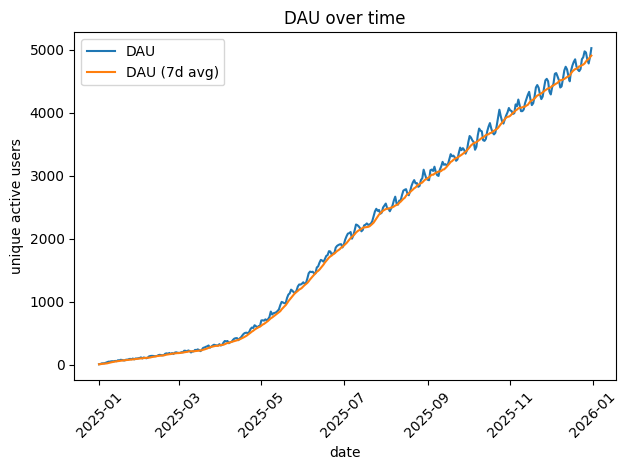

In [108]:
# Plot 1: DAU Over Time
plt.figure()
plt.plot(dau.index, dau.values, label="DAU")
dau_7 = dau.rolling(7, min_periods=1).mean()
plt.plot(dau_7.index, dau_7.values, label="DAU (7d avg)")
plt.title("DAU over time")
plt.xlabel("date")
plt.ylabel("unique active users")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

out = OUT_FIG / "dau_over_time.png"
plt.savefig(out, dpi=150)
print("Saved:", out)
plt.show()

In [109]:
# Reset variant to a single source of truth: users.variant
for c in ["variant", "variant_x", "variant_y"]:
    if c in daily_active_ud.columns:
        daily_active_ud = daily_active_ud.drop(columns=c)

daily_active_ud = daily_active_ud.merge(
    users[["user_id", "variant"]],
    on="user_id",
    how="left"
)

assert_true(daily_active_ud["variant"].notna().all(), "Some daily_active rows missing variant after join")
print(daily_active_ud["variant"].value_counts())

dau_by_variant = (
    daily_active_ud.groupby(["event_date","variant"])["user_id"]
    .nunique()
    .unstack("variant")
    .sort_index()
)
print("DAU by variant:")
display(dau_by_variant.head())


variant
treatment    376154
control      368409
Name: count, dtype: int64
DAU by variant:


variant,control,treatment
event_date,,
2025-01-01,7,3
2025-01-02,6,8
2025-01-03,12,12
2025-01-04,14,11
2025-01-05,11,15


Saved: ..\outputs\figures\dau_by_variant.png


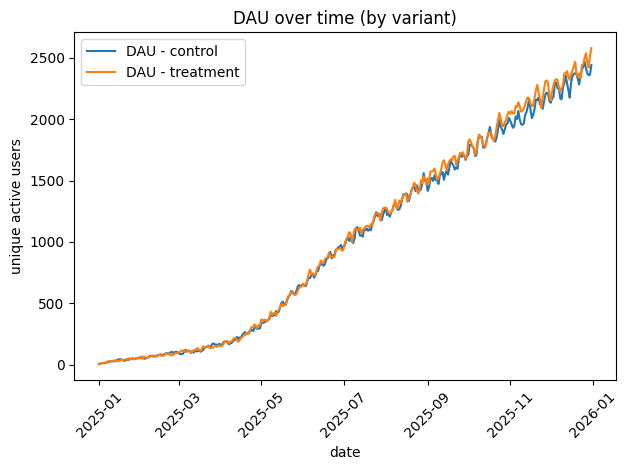

In [110]:
# Plot 2: DAU Split by Variant
plt.figure()
for col in dau_by_variant.columns:
    plt.plot(dau_by_variant.index, dau_by_variant[col].values, label=f"DAU - {col}")
plt.title("DAU over time (by variant)")
plt.xlabel("date")
plt.ylabel("unique active users")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

out = OUT_FIG / "dau_by_variant.png"
plt.savefig(out, dpi=150)
print("Saved:", out)
plt.show()

In [112]:
# -----------------------------
# Rollout date + pre-period A/A identity check (robust to low-volume noise)
# -----------------------------

START_DATE = min(users["signup_date"])          # inferred from data
EXP_START_DAY = 90                              # <-- change if you used a different exp_start_day
ROLLOUT_DATE = (pd.Timestamp(START_DATE) + pd.Timedelta(days=EXP_START_DAY)).date()

print("START_DATE  :", START_DATE)
print("ROLLOUT_DATE:", ROLLOUT_DATE, "(pre-period = strictly before this date)")

# Pre-period daily DAU by variant
pre = dau_by_variant.loc[dau_by_variant.index < ROLLOUT_DATE].dropna()
assert_true(len(pre) > 10, "Pre-period too short; check START_DATE/EXP_START_DAY")

# Filter out tiny-DAU days where percent gaps are meaningless
MIN_TOTAL_DAU = 50
pre_f = pre[(pre["control"] + pre["treatment"]) >= MIN_TOTAL_DAU].copy()
assert_true(len(pre_f) > 10, f"Too few pre-period days after MIN_TOTAL_DAU={MIN_TOTAL_DAU} filter")

ctrl = pre_f["control"].astype(float)
treat = pre_f["treatment"].astype(float)

# Symmetric % gap per day
gap_pct = (treat - ctrl) / (0.5 * (treat + ctrl))

mean_ratio = (treat.mean() / ctrl.mean()) if ctrl.mean() > 0 else np.nan
p95_abs_gap_pct = gap_pct.abs().quantile(0.95)
corr = np.corrcoef(ctrl.values, treat.values)[0, 1]

print("Pre-period identity stats (filtered, raw daily)")
print(" days kept                 :", len(pre_f), f"(MIN_TOTAL_DAU={MIN_TOTAL_DAU})")
print(" mean(treat)/mean(ctrl)    :", mean_ratio)
print(" 95th |gap| (% of avg day) :", pct(p95_abs_gap_pct))
print(" corr(ctrl, treat)         :", corr)

# Realistic tolerances for stochastic DAU
assert_true(abs(mean_ratio - 1.0) < 0.01, "Pre-period mean DAU differs by >1% between variants")
assert_true(p95_abs_gap_pct < 0.15, "Pre-period typical DAU gap too large (95th pct >15%)")
assert_true(corr > 0.97, "Pre-period DAU curves not tightly aligned (corr <= 0.97)")

# Optional: 7-day smoothed check (recommended for product-style telemetry)
pre_s = pre_f.rolling(7, min_periods=7).mean().dropna()
if len(pre_s) >= 10:
    ctrl_s = pre_s["control"].astype(float)
    treat_s = pre_s["treatment"].astype(float)
    gap_pct_s = (treat_s - ctrl_s) / (0.5 * (treat_s + ctrl_s))
    p95_abs_gap_pct_s = gap_pct_s.abs().quantile(0.95)
    corr_s = np.corrcoef(ctrl_s.values, treat_s.values)[0, 1]

    print("\nPre-period identity stats (7-day smoothed)")
    print(" 95th |gap| (% of avg day) :", pct(p95_abs_gap_pct_s))
    print(" corr(ctrl, treat)         :", corr_s)

    assert_true(corr_s > 0.98, "Smoothed pre-period curves not aligned (corr <= 0.98)")
    assert_true(p95_abs_gap_pct_s < 0.12, "Smoothed typical DAU gap too large (95th pct >12%)")

print("✅ Pre-period control vs treatment looks identical (within tolerance).")


START_DATE  : 2025-01-01
ROLLOUT_DATE: 2025-04-01 (pre-period = strictly before this date)
Pre-period identity stats (filtered, raw daily)
 days kept                 : 83 (MIN_TOTAL_DAU=50)
 mean(treat)/mean(ctrl)    : 0.9971428571428572
 95th |gap| (% of avg day) : 27.07%
 corr(ctrl, treat)         : 0.9526787615946976


AssertionError: Pre-period typical DAU gap too large (95th pct >15%)

Overall variant counts: {'treatment': 5041, 'control': 4959}


variant,control,treatment,total,treat_share
signup_date,,,,
2025-01-01,10,10,20,0.5
2025-01-02,10,10,20,0.5
2025-01-03,10,10,20,0.5
2025-01-04,10,10,20,0.5
2025-01-05,10,10,20,0.5
2025-01-06,10,10,20,0.5
2025-01-07,10,10,20,0.5
2025-01-08,10,10,20,0.5
2025-01-09,10,10,20,0.5


Treat share summary (daily):


count    365.000000
mean       0.503065
std        0.005855
min        0.500000
5%         0.500000
25%        0.500000
50%        0.500000
75%        0.500000
95%        0.515152
max        0.523810
Name: treat_share, dtype: float64

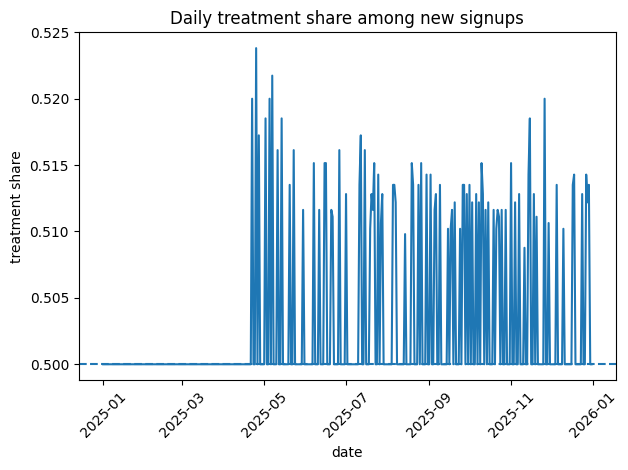

In [ ]:
# daily signup counts by variant
u = users.copy()
u["signup_date"] = pd.to_datetime(u["signup_date"])

signup_by_day = (
    u.groupby([u["signup_date"].dt.date, "variant"])["user_id"]
    .nunique()
    .unstack("variant")
    .fillna(0)
    .sort_index()
)

signup_by_day["total"] = signup_by_day.sum(axis=1)
signup_by_day["treat_share"] = signup_by_day.get("treatment", 0) / signup_by_day["total"].replace(0, np.nan)

print("Overall variant counts:", u["variant"].value_counts().to_dict())
display(signup_by_day.head(20))
print("Treat share summary (daily):")
display(signup_by_day["treat_share"].describe(percentiles=[0.05,0.25,0.5,0.75,0.95]))

# quick plot
plt.figure()
plt.plot(signup_by_day.index, signup_by_day["treat_share"].values)
plt.axhline(0.5, linestyle="--")
plt.title("Daily treatment share among new signups")
plt.xlabel("date")
plt.ylabel("treatment share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


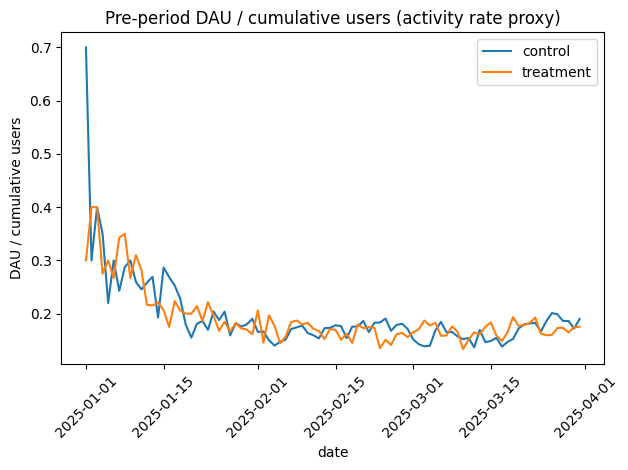

Corr of DAU rates (pre): 0.667161599684839


In [ ]:
# 1) Pre-period DAU by variant
pre = dau_by_variant.loc[dau_by_variant.index < ROLLOUT_DATE].dropna()

# 2) Build cumulative user base by variant (denominator)
u = users.copy()
u["signup_date"] = pd.to_datetime(u["signup_date"]).dt.date

signup_by_day = (
    u.groupby(["signup_date","variant"])["user_id"]
    .nunique()
    .unstack("variant")
    .fillna(0)
    .sort_index()
)

signup_by_day_cum = signup_by_day.cumsum()
signup_by_day_cum.columns = [f"{c}_cum" for c in signup_by_day_cum.columns]

# 3) Join denom onto DAU (align by date)
base = pre.join(signup_by_day_cum, how="left").ffill()

# 4) ✅ NORMALIZATION STEP (this is what I meant)
base["dau_rate_control"] = base["control"] / base["control_cum"].replace(0, np.nan)
base["dau_rate_treatment"] = base["treatment"] / base["treatment_cum"].replace(0, np.nan)


# normalize DAU by cumulative users to date (activity rate proxy)
base["dau_rate_control"] = base["control"] / base["control_cum"].replace(0, np.nan)
base["dau_rate_treatment"] = base["treatment"] / base["treatment_cum"].replace(0, np.nan)

plt.figure()
plt.plot(base.index, base["dau_rate_control"].values, label="control")
plt.plot(base.index, base["dau_rate_treatment"].values, label="treatment")
plt.title("Pre-period DAU / cumulative users (activity rate proxy)")
plt.xlabel("date")
plt.ylabel("DAU / cumulative users")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Corr of DAU rates (pre):", np.corrcoef(base["dau_rate_control"].dropna(), base["dau_rate_treatment"].dropna())[0,1])


In [ ]:
# Active Users Denominators
active_users_day = daily_active_ud.groupby("event_date")["user_id"].nunique().sort_index()
active_users_day_variant = (
    daily_active_ud.groupby(["event_date","variant"])["user_id"]
    .nunique()
    .unstack("variant")
    .sort_index()
)

display(active_users_day.head())
display(active_users_day_variant.head())

event_date
2025-01-01    10
2025-01-02    14
2025-01-03    24
2025-01-04    25
2025-01-05    26
Name: user_id, dtype: int64

variant,control,treatment
event_date,,
2025-01-01,7,3
2025-01-02,6,8
2025-01-03,12,12
2025-01-04,14,11
2025-01-05,11,15


In [ ]:
# Sessions per Active User (overall + variant)
sessions_day = sessions.copy()
sessions_day["date"] = sessions_day["session_start"].dt.date

sessions_cnt = sessions_day.groupby("date")["session_id"].count().sort_index()
avg_sessions_per_active = (sessions_cnt / active_users_day).replace([np.inf, -np.inf], np.nan)

# variant split
sessions_day_v = sessions_day.merge(users[["user_id","variant"]], on="user_id", how="left")
sessions_cnt_v = (
    sessions_day_v.groupby(["date","variant"])["session_id"]
    .count()
    .unstack("variant")
    .sort_index()
)

avg_sessions_per_active_v = (sessions_cnt_v / active_users_day_variant).replace([np.inf, -np.inf], np.nan)

display(avg_sessions_per_active.head())
display(avg_sessions_per_active_v.head())

date
2025-01-01    1.400000
2025-01-02    1.785714
2025-01-03    1.541667
2025-01-04    1.480000
2025-01-05    1.269231
dtype: float64

variant,control,treatment
date,,
2025-01-01,1.428571,1.333333
2025-01-02,1.833333,1.750000
2025-01-03,1.666667,1.416667
2025-01-04,1.500000,1.454545
2025-01-05,1.181818,1.333333


Saved: ..\outputs\figures\avg_sessions_per_active_overall.png


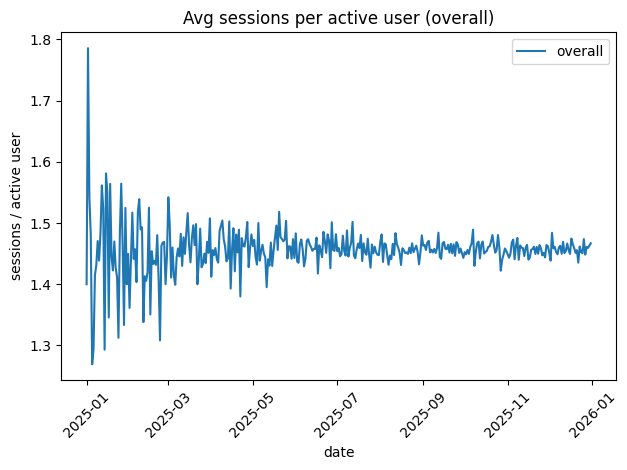

Saved: ..\outputs\figures\avg_sessions_per_active_by_variant.png


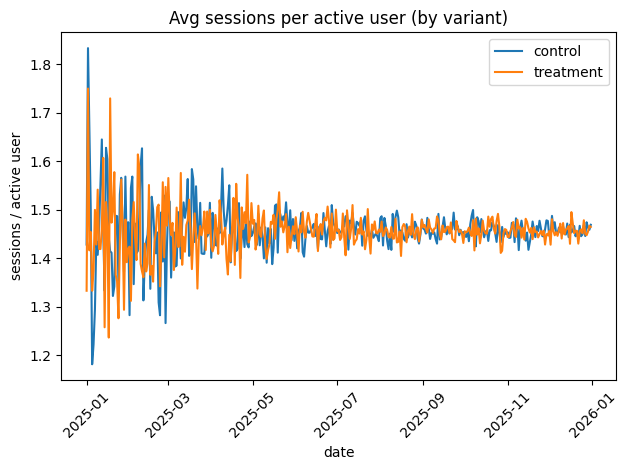

In [ ]:
# Plot 3: Avg Sessions per Active User
plt.figure()
plt.plot(avg_sessions_per_active.index, avg_sessions_per_active.values, label="overall")
plt.title("Avg sessions per active user (overall)")
plt.xlabel("date")
plt.ylabel("sessions / active user")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

out = OUT_FIG / "avg_sessions_per_active_overall.png"
plt.savefig(out, dpi=150)
print("Saved:", out)
plt.show()

plt.figure()
for col in avg_sessions_per_active_v.columns:
    plt.plot(avg_sessions_per_active_v.index, avg_sessions_per_active_v[col].values, label=col)
plt.title("Avg sessions per active user (by variant)")
plt.xlabel("date")
plt.ylabel("sessions / active user")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

out = OUT_FIG / "avg_sessions_per_active_by_variant.png"
plt.savefig(out, dpi=150)
print("Saved:", out)
plt.show()

In [ ]:
# Avg Streak Length Over Time
streak_evt = events[events["event_name"] == "streak_incremented"].copy()

avg_streak = streak_evt.groupby("event_date")["streak_length"].mean().sort_index()
avg_streak_v = (
    streak_evt.groupby(["event_date","variant"])["streak_length"]
    .mean()
    .unstack("variant")
    .sort_index()
)

display(avg_streak.head())
display(avg_streak_v.head())

event_date
2025-01-01    1.000000
2025-01-02    1.214286
2025-01-03    1.375000
2025-01-04    1.720000
2025-01-05    1.461538
Name: streak_length, dtype: float64

variant,control,treatment
event_date,,
2025-01-01,1.000000,1.000000
2025-01-02,1.333333,1.125000
2025-01-03,1.333333,1.416667
2025-01-04,1.857143,1.545455
2025-01-05,1.454545,1.466667


Saved: ..\outputs\figures\avg_streak_overall.png


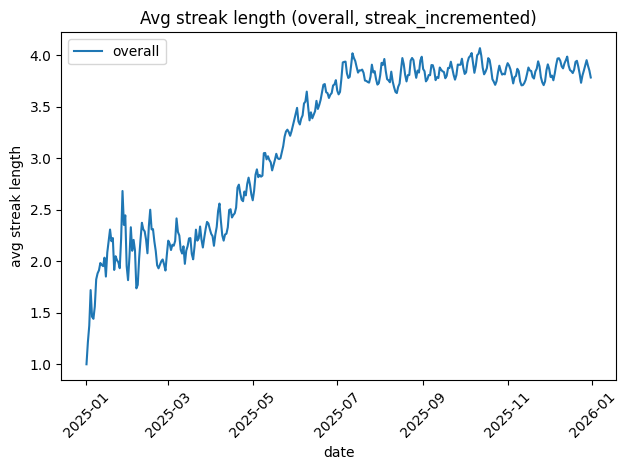

Saved: ..\outputs\figures\avg_streak_by_variant.png


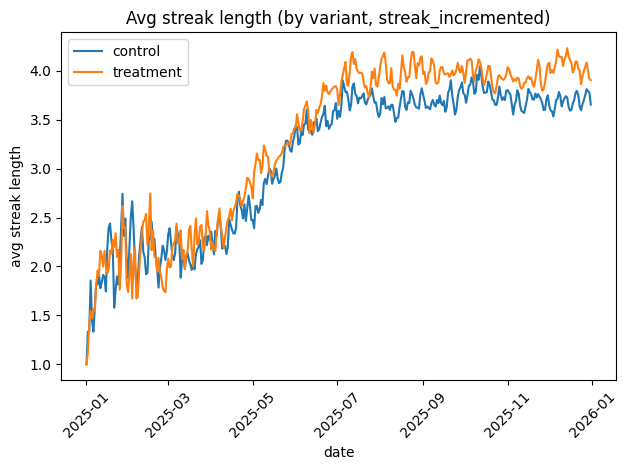

In [ ]:
# Plot 4: Avg Streak Length Over Time
plt.figure()
plt.plot(avg_streak.index, avg_streak.values, label="overall")
plt.title("Avg streak length (overall, streak_incremented)")
plt.xlabel("date")
plt.ylabel("avg streak length")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

out = OUT_FIG / "avg_streak_overall.png"
plt.savefig(out, dpi=150)
print("Saved:", out)
plt.show()

plt.figure()
for col in avg_streak_v.columns:
    plt.plot(avg_streak_v.index, avg_streak_v[col].values, label=col)
plt.title("Avg streak length (by variant, streak_incremented)")
plt.xlabel("date")
plt.ylabel("avg streak length")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

out = OUT_FIG / "avg_streak_by_variant.png"
plt.savefig(out, dpi=150)
print("Saved:", out)
plt.show()

In [ ]:
# Funnel Sanity (Aggregate)
# daily counts (events)
daily_counts = (
    events[events["event_name"].isin(["app_open","lesson_started","lesson_completed"])]
    .groupby(["event_date","event_name"])["event_id"]
    .count()
    .unstack("event_name")
    .fillna(0)
    .sort_index()
)

# daily unique users (users)
daily_users = (
    events[events["event_name"].isin(["app_open","lesson_started","lesson_completed"])]
    .drop_duplicates(subset=["event_date","event_name","user_id"])
    .groupby(["event_date","event_name"])["user_id"]
    .count()
    .unstack("event_name")
    .fillna(0)
    .sort_index()
)

display(daily_counts.head())
display(daily_users.head())

# invariants (allowing small stochastic oddities is usually unnecessary since your generator enforces the ordering)
assert_true((daily_counts["lesson_started"] <= daily_counts["app_open"]).all(),
            "Found days where lesson_started > app_open (event counts)")
assert_true((daily_counts["lesson_completed"] <= daily_counts["lesson_started"]).all(),
            "Found days where lesson_completed > lesson_started (event counts)")

assert_true((daily_users["lesson_started"] <= daily_users["app_open"]).all(),
            "Found days where unique lesson_started users > unique app_open users")
assert_true((daily_users["lesson_completed"] <= daily_users["lesson_started"]).all(),
            "Found days where unique lesson_completed users > unique lesson_started users")

print("✅ Funnel aggregate sanity checks passed.")

event_name,app_open,lesson_completed,lesson_started
event_date,,,
2025-01-01,14,9,11
2025-01-02,25,15,18
2025-01-03,37,25,32
2025-01-04,37,25,33
2025-01-05,33,23,25


event_name,app_open,lesson_completed,lesson_started
event_date,,,
2025-01-01,10,6,7
2025-01-02,14,9,12
2025-01-03,24,20,22
2025-01-04,25,19,23
2025-01-05,26,17,19


✅ Funnel aggregate sanity checks passed.


In [ ]:
# Funnel Ordering Within Session (Stronger)
# For sessions with both lesson_started and lesson_completed, ensure ordering
ls = events[events["event_name"] == "lesson_started"][["user_id","session_id","event_time"]].rename(columns={"event_time":"t_started"})
lc = events[events["event_name"] == "lesson_completed"][["user_id","session_id","event_time"]].rename(columns={"event_time":"t_completed"})

# join on user+session
j = ls.merge(lc, on=["user_id","session_id"], how="inner")

# if multiple per session, take min started and min completed to check basic ordering
j2 = j.groupby(["user_id","session_id"], as_index=False).agg(
    t_started=("t_started","min"),
    t_completed=("t_completed","min")
)

viol = j2[j2["t_completed"] < j2["t_started"]]
print("Ordering violations:", len(viol))
if len(viol) > 0:
    display(viol.head(20))

assert_true(len(viol) == 0, "Found lesson_completed earlier than lesson_started in same session")
print("✅ Within-session ordering checks passed.")

Ordering violations: 0
✅ Within-session ordering checks passed.


In [ ]:
# Pre vs Post Summary Table
def window_mask(dates, start=None, end=None):
    m = pd.Series(True, index=dates)
    if start is not None:
        m &= (dates >= start)
    if end is not None:
        m &= (dates < end)
    return m

# build metric frames aligned by day
metric_day = pd.DataFrame({
    "dau_control": dau_by_variant.get("control"),
    "dau_treatment": dau_by_variant.get("treatment"),
    "sess_per_active_control": avg_sessions_per_active_v.get("control"),
    "sess_per_active_treatment": avg_sessions_per_active_v.get("treatment"),
    "avg_streak_control": avg_streak_v.get("control"),
    "avg_streak_treatment": avg_streak_v.get("treatment"),
}).sort_index()

pre_mask = metric_day.index < ROLLOUT_DATE
post_mask = metric_day.index >= ROLLOUT_DATE

def summarize(metric_day: pd.DataFrame, mask: pd.Series, label: str) -> pd.DataFrame:
    out = {}
    for base in ["dau", "sess_per_active", "avg_streak"]:
        c = metric_day.loc[mask, f"{base}_control"].mean()
        t = metric_day.loc[mask, f"{base}_treatment"].mean()
        out[base] = {"control": c, "treatment": t, "diff_pct": (t/c - 1.0) if c and c > 0 else np.nan}
    df = pd.DataFrame(out).T
    df["window"] = label
    return df.reset_index(names="metric")

pre_sum = summarize(metric_day, pre_mask, "pre")
post_sum = summarize(metric_day, post_mask, "post")
summary = pd.concat([pre_sum, post_sum], ignore_index=True)

display(summary)

summary.to_csv(OUT_TAB / "pre_post_summary.csv", index=False)
print("Saved:", OUT_TAB / "pre_post_summary.csv")

,metric,control,treatment,diff_pct,window
0,dau,78.722222,78.544444,-0.002258,pre
1,sess_per_active,1.454658,1.448470,-0.004254,pre
2,avg_streak,2.071045,2.087991,0.008182,pre
3,dau,1313.905455,1342.127273,0.021479,post
4,sess_per_active,1.457922,1.457771,-0.000104,post
5,avg_streak,3.451634,3.684269,0.067399,post


Saved: ..\outputs\tables\pre_post_summary.csv


In [ ]:
# Save Key Tables
daily_counts.to_csv(OUT_TAB / "daily_funnel_event_counts.csv")
daily_users.to_csv(OUT_TAB / "daily_funnel_unique_users.csv")
dau.to_csv(OUT_TAB / "dau.csv", header=True)
dau_by_variant.to_csv(OUT_TAB / "dau_by_variant.csv")

print("Saved tables to:", OUT_TAB)

Saved tables to: ..\outputs\tables
